In [1]:
# Importing necessary libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew 
import warnings

In [2]:
# Setting seaborn style and colours
sns.set_style("whitegrid")
sns.color_palette("muted", 10)
sns.set_palette("muted", 10)

In [3]:
user = pd.read_csv("dataset_test_user.csv")

In [4]:
user.head()

,visitor_id,has_inquired,has_an_account,article_pageviews,artist_pageviews,artwork_pageviews
0,0,False,False,0.0,0.0,1.0
1,1,True,False,0.0,0.0,1.0
2,2,True,True,0.0,0.0,1.0
3,3,False,False,0.0,1.0,0.0
4,4,False,False,0.0,0.0,1.0


In [5]:
user.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2611 entries, 0 to 2610
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   visitor_id         2611 non-null   int64  
 1   has_inquired       2611 non-null   bool   
 2   has_an_account     2611 non-null   bool   
 3   article_pageviews  2611 non-null   float64
 4   artist_pageviews   2611 non-null   float64
 5   artwork_pageviews  2611 non-null   float64
dtypes: bool(2), float64(3), int64(1)
memory usage: 86.8 KB


# Questions:

    1. What observations can you make about inquirers and non-inquirers's behavior based on this dataset?

    2. Using the Users dataset, build a machine learning model to predict who will inquire.

    􏰃􏰁3. Evaluate the performance of your model.

    4. What other features would you want to add to the dataset to build a stronger model?

    5. What are some recommendations you can make to improve our product for commercial users based on the model that you built?

In [6]:
user.describe()

,visitor_id,article_pageviews,artist_pageviews,artwork_pageviews
count,2611.0000,2611.000000,2611.000000,2611.000000
mean,1305.0000,0.210647,0.409422,0.525469
std,753.8751,0.436875,0.785727,1.007454
min,0.0000,0.000000,0.000000,0.000000
25%,652.5000,0.000000,0.000000,0.000000
50%,1305.0000,0.000000,0.000000,0.000000
75%,1957.5000,0.000000,1.000000,1.000000
max,2610.0000,3.000000,14.000000,15.000000


In [7]:
# for inquiries: changing boolean type into integers, meaning 0=False and 1=True
user["has_inquired"] = user["has_inquired"].apply(lambda x: 1*x)
user.head()

,visitor_id,has_inquired,has_an_account,article_pageviews,artist_pageviews,artwork_pageviews
0,0,0,False,0.0,0.0,1.0
1,1,1,False,0.0,0.0,1.0
2,2,1,True,0.0,0.0,1.0
3,3,0,False,0.0,1.0,0.0
4,4,0,False,0.0,0.0,1.0


In [8]:
# for accounts: changing boolean type into integers, meaning 0=False and 1=True
user["has_an_account"] = user["has_an_account"].apply(lambda x: 1*x)
user.head()

,visitor_id,has_inquired,has_an_account,article_pageviews,artist_pageviews,artwork_pageviews
0,0,0,0,0.0,0.0,1.0
1,1,1,0,0.0,0.0,1.0
2,2,1,1,0.0,0.0,1.0
3,3,0,0,0.0,1.0,0.0
4,4,0,0,0.0,0.0,1.0


### 1. What observations can you make about inquirers and non-inquirers's behavior based on this dataset?

In [9]:
user["has_inquired"].value_counts()

0    1500
1    1111
Name: has_inquired, dtype: int64

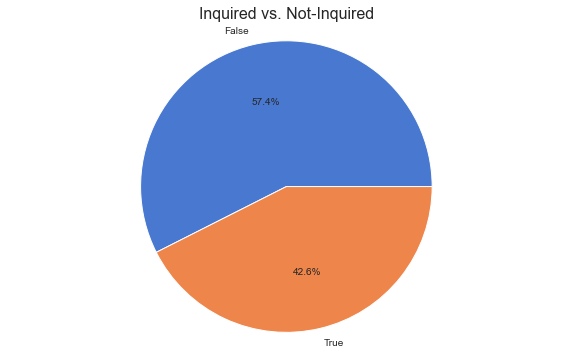

In [10]:
plt.figure(figsize=(10,6))
plt.pie(user["has_inquired"].value_counts(),labels=["False", "True"], autopct='%1.1f%%')
plt.axis('equal')
plt.title("Inquired vs. Not-Inquired", fontsize=16)
plt.show()

**Results**
There are more users who have not yet inquired.

In [11]:
user.groupby("has_inquired")["has_an_account"].mean()

has_inquired
0    0.118667
1    0.786679
Name: has_an_account, dtype: float64

In [12]:
user.groupby("has_inquired")["article_pageviews"].mean()

has_inquired
0    0.320000
1    0.063006
Name: article_pageviews, dtype: float64

In [13]:
user.groupby("has_inquired")["artist_pageviews"].mean()

has_inquired
0    0.324667
1    0.523852
Name: artist_pageviews, dtype: float64

In [14]:
user.groupby("has_inquired")["artwork_pageviews"].mean()

has_inquired
0    0.257333
1    0.887489
Name: artwork_pageviews, dtype: float64

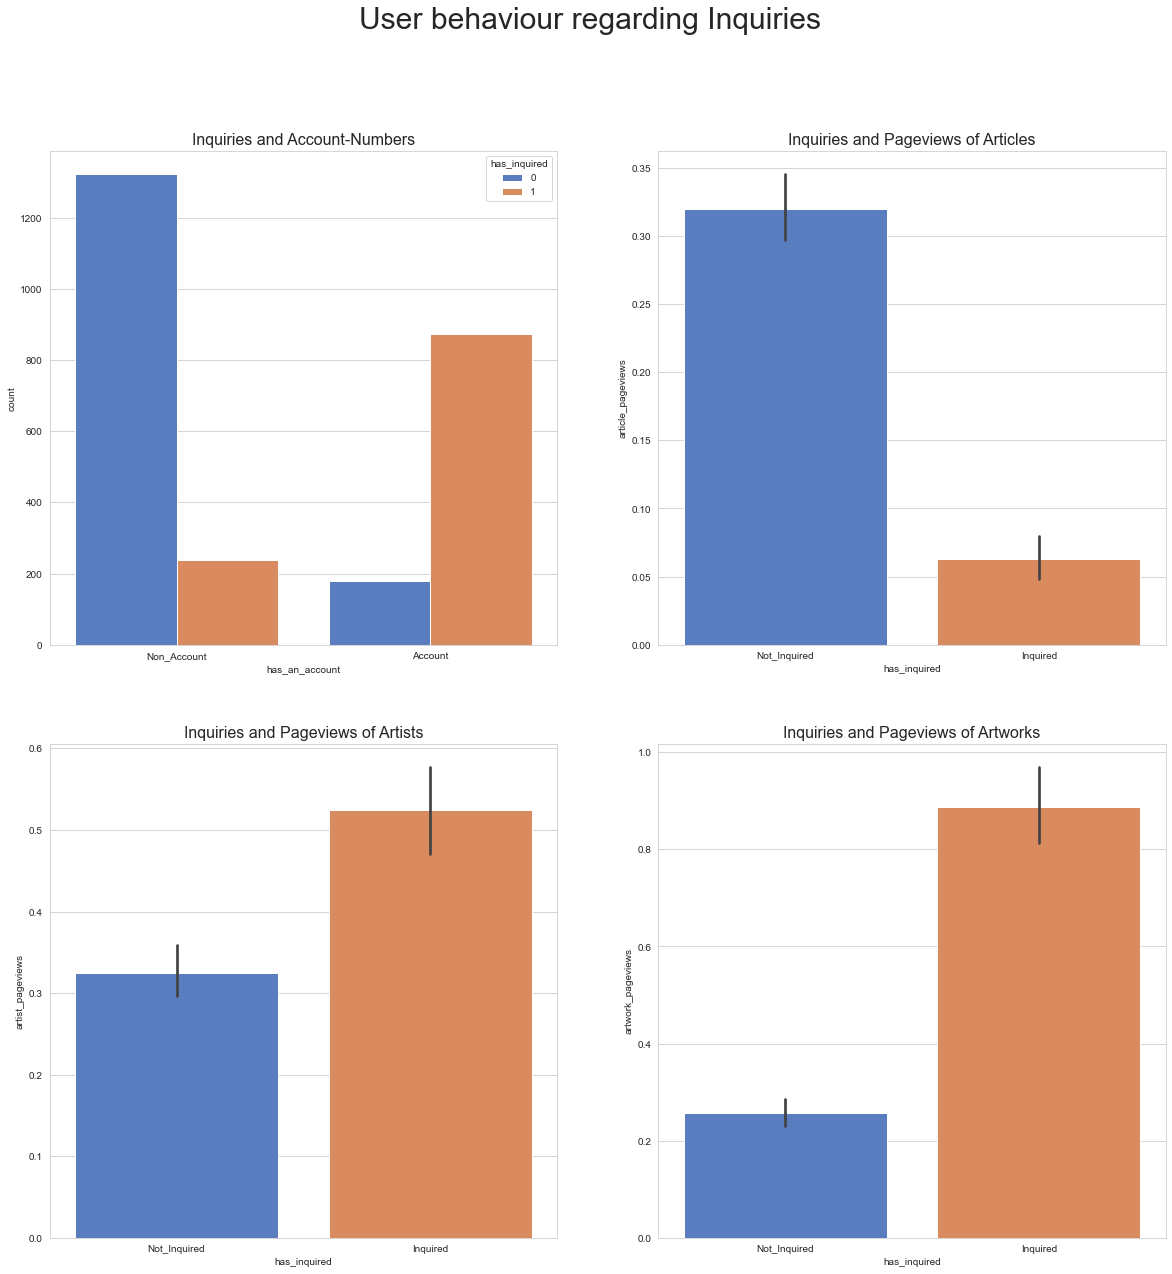

In [15]:
warnings.filterwarnings('ignore')

fig, ax = plt.subplots(ncols=2, nrows=2,sharex=False,sharey=False, figsize=(20,20))
plt.suptitle("User behaviour regarding Inquiries", fontsize = 30);

f1 = sns.countplot(x='has_an_account', hue="has_inquired", data=user, ax=ax[0,0]);
f1.set_title("Inquiries and Account-Numbers", fontsize=16);
f1.set_xticklabels(["Non_Account","Account"]);

f2 = sns.barplot(y='article_pageviews', x="has_inquired", data=user, ax=ax[0,1]);
f2.set_title("Inquiries and Pageviews of Articles", fontsize=16);
f2.set_xticklabels(["Not_Inquired","Inquired"]);

f3 = sns.barplot(y='artist_pageviews', x="has_inquired", data=user, ax=ax[1,0]);
f3.set_title("Inquiries and Pageviews of Artists", fontsize=16);
f3.set_xticklabels(["Not_Inquired","Inquired"]);

f4 = sns.barplot(y='artwork_pageviews', x="has_inquired", data=user, ax=ax[1,1]);
f4.set_title("Inquiries and Pageviews of Artworks", fontsize=16);
f4.set_xticklabels(["Not_Inquired","Inquired"]);

**Results**

Most of the user, who have inquired, also have an account.
Among the user, who have inquired, the pageviews for Artworks are the highest.

In [17]:
df_corr=user.iloc[: , 1:]
df_corr

,has_inquired,has_an_account,article_pageviews,artist_pageviews,artwork_pageviews
0,0,0,0.0,0.0,1.0
1,1,0,0.0,0.0,1.0
2,1,1,0.0,0.0,1.0
3,0,0,0.0,1.0,0.0
4,0,0,0.0,0.0,1.0
...,...,...,...,...,...
2606,0,0,0.0,1.0,0.0
2607,1,0,0.0,1.0,0.0
2608,0,0,0.0,1.0,0.0
2609,0,1,0.0,0.0,0.0


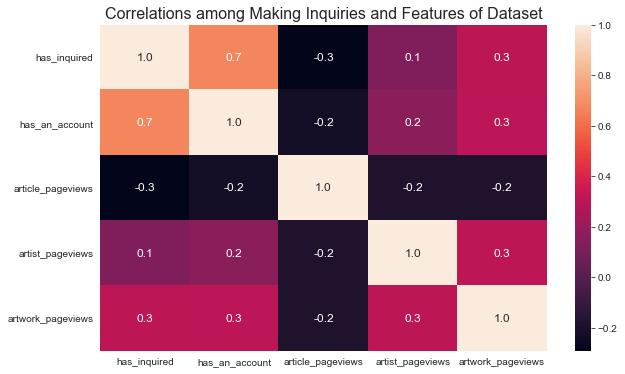

In [18]:
plt.figure(figsize = (10,6))
sns.heatmap(df_corr.corr(), annot=True, annot_kws={"size": 12}, fmt="1.1f");
plt.title("Correlations among Making Inquiries and Features of Dataset", fontsize=16);

**Results**

Also the correlation heatmap shows, that making an inquiry is correlated the most with having an account, as well as the number of artwork pageviews.

### 2. Using the Users dataset, build a machine learning model to predict who will inquire.

In [20]:
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold
from sklearn import linear_model, svm
from sklearn.svm import SVC
from scipy import stats
from scipy.stats import randint
from sklearn.tree import DecisionTreeClassifier 
from sklearn.metrics import plot_confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, confusion_matrix, classification_report, make_scorer, fbeta_score, plot_confusion_matrix, roc_auc_score, accuracy_score, recall_score, precision_score

In [21]:
y = user['has_inquired']
X = user.iloc[:, -4:]

In [22]:
y

0       0
1       1
2       1
3       0
4       0
       ..
2606    0
2607    1
2608    0
2609    0
2610    1
Name: has_inquired, Length: 2611, dtype: int64

In [23]:
X

,has_an_account,article_pageviews,artist_pageviews,artwork_pageviews
0,0,0.0,0.0,1.0
1,0,0.0,0.0,1.0
2,1,0.0,0.0,1.0
3,0,0.0,1.0,0.0
4,0,0.0,0.0,1.0
...,...,...,...,...
2606,0,0.0,1.0,0.0
2607,0,0.0,1.0,0.0
2608,0,0.0,1.0,0.0
2609,1,0.0,0.0,0.0


In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .3, random_state=25)

**Random Forest**

In [25]:
# Create the model with 100 trees
rf = RandomForestClassifier(n_estimators=100, 
                               random_state=50, 
                               max_features = 'sqrt',
                               n_jobs=-1, verbose = 1)

In [26]:
rf.fit(X_train, y_train)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished


RandomForestClassifier(max_features='sqrt', n_jobs=-1, random_state=50,
                       verbose=1)

### 3. Evaluate the performance of your model.



In [27]:
rf_predictions = rf.predict(X_test)

[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


In [28]:
print(classification_report(y_test, rf_predictions))

              precision    recall  f1-score   support

           0       0.84      0.87      0.85       434
           1       0.83      0.79      0.81       350

    accuracy                           0.83       784
   macro avg       0.83      0.83      0.83       784
weighted avg       0.83      0.83      0.83       784



[Parallel(n_jobs=8)]: Using backend ThreadingBackend with 8 concurrent workers.
[Parallel(n_jobs=8)]: Done  34 tasks      | elapsed:    0.0s
[Parallel(n_jobs=8)]: Done 100 out of 100 | elapsed:    0.0s finished


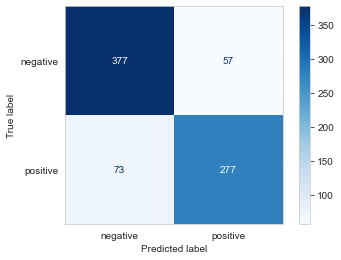

In [29]:
disp = plot_confusion_matrix(rf, X_test, y_test,
                             display_labels=['negative', 'positive'],
                             cmap=plt.cm.Blues, 
                             normalize=None,
                             values_format = 'd')

plt.grid(False)
plt.show()

In [30]:
features = ["has_an_account", "article_pageviews", "artist_pageviews", "artwork_pageviews"]
rf_features = pd.DataFrame({'feature': features,
                   'importance': rf.feature_importances_}).\
                    sort_values('importance', ascending = False)
rf_features.head(8)

,feature,importance
0,has_an_account,0.769524
3,artwork_pageviews,0.129239
1,article_pageviews,0.073356
2,artist_pageviews,0.027881


**Result**

Accuracy of the model is at a high level.

The True Negative rate is higher than the True Positive rate (recall). In order to get a higher recall, one option would be to lower the treshold.

Among the features, whether the user has an account or not, is the most important feature within this model.

### 4. What other features would you want to add to the dataset to build a stronger model?

Other information about the user would be helpful in order to predict, whether the user will inquire or not.
F.e. age and job could be important features as well.

### 5. What are some recommendations you can make to improve our product for commercial users based on the model that you built?

- It seems that users who have an account have a more binding connection to artsy. By offering special offers to those who have an account might on the one hand increase the amount of inquiries amongst people with an account - on the other hand it might make people to register fo an account - which again might lead to a more binding connection to artsy.

- Advertising the artwork part on the artsy page more, since appearently this leads to more inquiries.